<a href="https://colab.research.google.com/github/Shahad-Hossain/nasa-image-enhancement/blob/main/Homework_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import math
import os
from typing import List

from google.colab import drive

from skimage.feature import graycomatrix, graycoprops
from skimage.transform import resize
from tqdm.notebook import tqdm

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def loadImageFromDrive(filename: str, driveFolder: str = 'CSC475/Homework7', color="RGB") -> np.ndarray:
  """
  Loads an image from Google Drive into a NumPy array.
  """
  try:
    filePath = f"/content/drive/MyDrive/{driveFolder}/{filename}"

    loadedImgBgr = cv.imread(filePath)

    print(f'Image successfully loaded from: {filePath}')
    if color == "gray":
      return cv.cvtColor(loadedImgBgr, cv.COLOR_BGR2GRAY)

    if color == "RGB":
      return cv.cvtColor(loadedImgBgr, cv.COLOR_BGR2RGB)

    if color == "BGR":
      return loadedImgBgr

  except Exception as e:
    print(f'Error loading image from Drive: {e}')
    return None

In [ ]:
def show(image: np.ndarray, cmap=None, title=None):
    try:
        plt.imshow(image, cmap=cmap)
        plt.title(title)
        plt.axis("off")
        plt.show()
    except Exception as e:
        return ValueError(f"Unknown error occured: {e}")

Image successfully loaded from: /content/drive/MyDrive/CSC475/Homework7//image 9.jpg
Image successfully loaded from: /content/drive/MyDrive/CSC475/Homework7//image 9.jpg


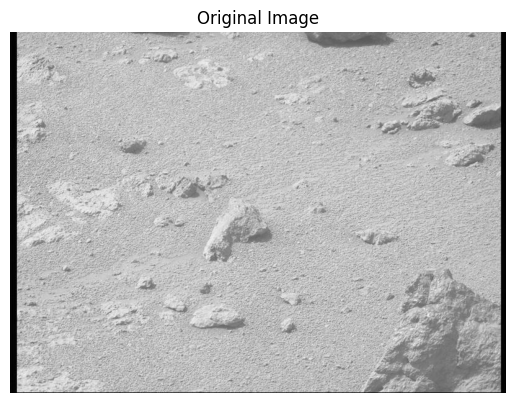

In [ ]:
filename = "/image 9.jpg"
marsImage = loadImageFromDrive(filename, color="RGB")
grayMarsImage = loadImageFromDrive(filename, color="gray")

show(grayMarsImage, cmap="gray", title="Original Image")

In [ ]:
def compute_glcm(image, distances=[1], angles=[0, 45, 90, 135]):
    # Reduce gray levels (important!)
    image = (image / 32).astype(np.uint8)  # 0–255 → 0–7

    glcm = graycomatrix(
        image,
        distances=distances,
        angles=angles,
        levels=8,
        symmetric=True,
        normed=True
    )

    return glcm

In [ ]:
def extract_haralick_features(glcm):
    features = {}

    features['contrast'] = graycoprops(glcm, 'contrast')[0, 0]
    features['energy'] = graycoprops(glcm, 'energy')[0, 0]
    features['homogeneity'] = graycoprops(glcm, 'homogeneity')[0, 0]
    features['correlation'] = graycoprops(glcm, 'correlation')[0, 0]

    # Entropy (manual)
    p = glcm[:, :, 0, 0]
    p = p[p > 0]
    features['entropy'] = -np.sum(p * np.log(p))

    return features

In [ ]:
def show_glcm(glcm):
    matrix = glcm[:, :, 0, 0]
    show(matrix, cmap="gray", title="GLCM Matrix All Degrees")

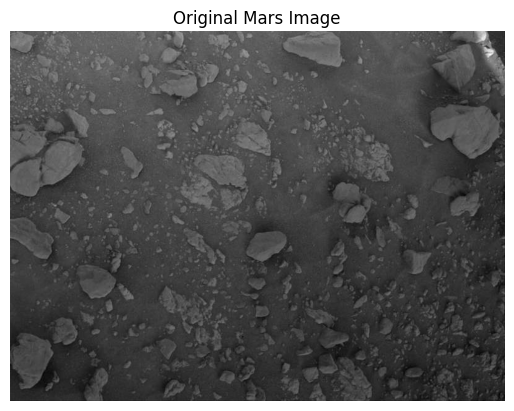

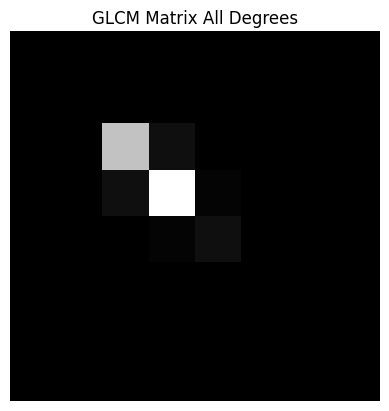

Haralick Features:
contrast: 0.0820
energy: 0.6351
homogeneity: 0.9590
correlation: 0.8728
entropy: 1.1392


In [ ]:
def haralick_pipeline(image):
    show(image, cmap="gray", title="Original Mars Image")

    glcm = compute_glcm(image)
    show_glcm(glcm)

    features = extract_haralick_features(glcm)

    print("Haralick Features:")
    for k, v in features.items():
        print(f"{k}: {v:.4f}")

    return features

features = haralick_pipeline(grayMarsImage)

In [ ]:
grayMarsImage = cv.GaussianBlur(grayMarsImage, (3, 3), 0)
def generate_haralick_maps(image: np.ndarray, window_size: int = 15, stride: int = 3):
    """
    Computes local Haralick features using a sliding window to generate feature maps.

    Args:
        image: Grayscale input image.
        window_size: Size of the sliding window (must be odd).
        stride: How many pixels to skip to speed up processing.
    """
    # 1. Reduce gray levels to 8 (0-7) just like in Block 5
    img_quantized = (image / 32).astype(np.uint8)

    h, w = img_quantized.shape
    half_w = window_size // 2

    # 2. Pad the image so we can process the edges properly
    padded_img = np.pad(img_quantized, half_w, mode='reflect')

    # 3. Create smaller empty arrays based on our stride
    out_h = (h + stride - 1) // stride
    out_w = (w + stride - 1) // stride

    maps = {
        'contrast': np.zeros((out_h, out_w)),
        'energy': np.zeros((out_h, out_w)),
        'homogeneity': np.zeros((out_h, out_w)),
        'correlation': np.zeros((out_h, out_w)),
        'entropy': np.zeros((out_h, out_w))
    }

    print(f"Calculating Haralick maps with window={window_size} and stride={stride}...")

    # 4. Slide the window across the image
    for out_y, y in enumerate(tqdm(range(0, h, stride), desc="Rows processed")):
        for out_x, x in enumerate(range(0, w, stride)):

            # Extract the local patch
            window = padded_img[y : y + window_size, x : x + window_size]

            # Compute GLCM for the patch
            glcm = graycomatrix(
                window,
                distances=[1],
                angles=[0],
                levels=8,
                symmetric=True,
                normed=True
            )

            # Extract features and assign to the corresponding pixel in the maps
            maps['contrast'][out_y, out_x] = graycoprops(glcm, 'contrast')[0, 0]
            maps['energy'][out_y, out_x] = graycoprops(glcm, 'energy')[0, 0]
            maps['homogeneity'][out_y, out_x] = graycoprops(glcm, 'homogeneity')[0, 0]
            maps['correlation'][out_y, out_x] = graycoprops(glcm, 'correlation')[0, 0]

            # Entropy (manual)
            p = glcm[:, :, 0, 0]
            p = p[p > 0]
            maps['entropy'][out_y, out_x] = -np.sum(p * np.log(p))

    # 5. Resize maps back to original image shape
    for key in maps.keys():
        maps[key] = resize(maps[key], (h, w), mode='reflect', anti_aliasing=True)

    return maps

def plot_haralick_maps(image, maps):
    """Plots the original image alongside its 5 Haralick feature maps."""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()

    # Plot original
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title("Original Mars Image")
    axes[0].axis("off")

    # Plot each map
    features = ['contrast', 'energy', 'homogeneity', 'correlation', 'entropy']
    for i, feat in enumerate(features):
        ax = axes[i + 1]
        im = ax.imshow(maps[feat], cmap='magma') # 'magma' or 'viridis' is great for heatmaps
        ax.set_title(feat.capitalize())
        ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

# Run the pipeline
# Note: If your image is very large (e.g., > 1000x1000), consider increasing the stride to 4 or 5
feature_maps = generate_haralick_maps(grayMarsImage, window_size=9, stride=1)
plot_haralick_maps(grayMarsImage, feature_maps)

In [ ]:
def show_single_haralick_map(feature_map, title="Haralick Feature"):
    """
    Displays a single Haralick feature map with a colorbar.

    Args:
        feature_map: The 2D numpy array (e.g., feature_maps['contrast'])
        title: The string title for the plot
    """
    plt.figure(figsize=(10, 7))

    # Using 'magma' as it provides great contrast for feature intensity
    im = plt.imshow(feature_map, cmap='magma')

    plt.title(f"{title.capitalize()} Map", fontsize=15)
    plt.axis("off")

    # Add a colorbar so we can see the actual values
    plt.colorbar(im, fraction=0.046, pad=0.04)

    plt.show()

# Example Usage:
show_single_haralick_map(feature_maps['contrast'], "Contrast")
show_single_haralick_map(feature_maps['entropy'], "Entropy")

In [ ]:
show(feature_maps['contrast'], cmap="gray", title="Contrast Map")

In [ ]:
show(feature_maps['correlation'], cmap="gray", title="Correlation Map")

In [ ]:
show(feature_maps['entropy'], cmap="gray", title="Entrophy Map")

In [ ]:
show(feature_maps['correlation'], cmap="gray")

In [ ]:
show(feature_maps['energy'], cmap="gray")

Image successfully loaded from: /content/drive/MyDrive/CSC475/Homework7//image 10.jpg
Image successfully loaded from: /content/drive/MyDrive/CSC475/Homework7//image 10.jpg


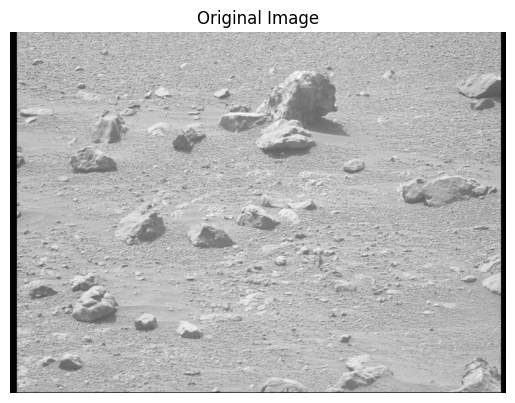

In [ ]:
filename = "/image 10.jpg"
marsImage = loadImageFromDrive(filename, color="RGB")
grayMarsImage = loadImageFromDrive(filename, color="gray")

show(grayMarsImage, cmap="gray", title="Original Image")

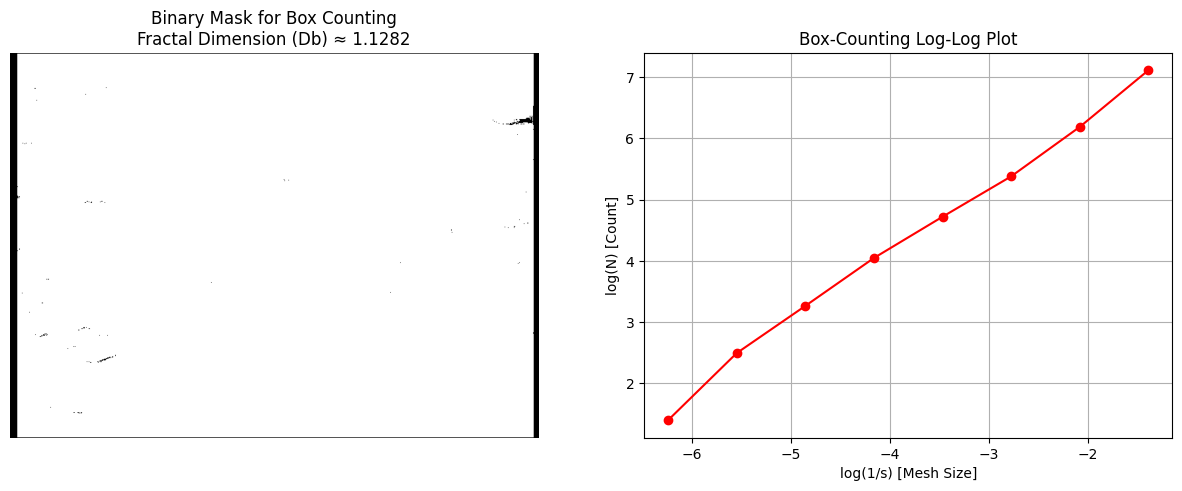

The calculated Fractal Dimension is: 1.1282


In [ ]:
def calculate_box_counting(image: np.ndarray):
    """
    Implements the Box-Counting Dimension (Db) as shown in the lecture slides.
    Db = [LogN(s) - LogN(s1)] / [Log(s) - Log(s1)]
    """
    # 1. Binarize the image (Fractal dimension needs a binary mask)
    # We use Otsu's threshold to automatically find the best split
    _, binary = cv.threshold(image, 0, 255, cv.THRESH_BINARY | cv.THRESH_OTSU)
    binary = cv.bitwise_not(binary)

    # Get the image dimensions
    h, w = binary.shape
    p = min(h, w)

    # Determine powers of 2 for grid sizes (s)
    # This ensures we can evenly divide the image into grids
    n = int(np.log2(p))
    scales = 2**np.arange(n, 1, -1) # e.g., 256, 128, 64, 32, 16, 8, 4

    counts = []
    for s in scales:
        count = 0
        # Slide a grid of size 's' over the image
        for y in range(0, h, s):
            for x in range(0, w, s):
                # If any pixel in this box is "on" (white), count the box
                if np.any(binary[y:y+s, x:x+s] > 0):
                    count += 1
        counts.append(count)

    # Calculate the slope (Db) using a linear regression on the log-log scale
    coeffs = np.polyfit(np.log(1/scales), np.log(counts), 1)
    fractal_dimension = coeffs[0]

    return fractal_dimension, scales, counts

def show_box_counting_analysis(image):
    """Visualizes the binary image and the log-log plot for Db."""
    db, scales, counts = calculate_box_counting(image)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Show the Binary Mask
    _, binary = cv.threshold(image, 0, 255, cv.THRESH_BINARY | cv.THRESH_OTSU)
    axes[0].imshow(binary, cmap='gray')
    axes[0].set_title(f"Binary Mask for Box Counting\nFractal Dimension (Db) ≈ {db:.4f}")
    axes[0].axis("off")

    # Show the Log-Log Plot
    axes[1].plot(np.log(1/scales), np.log(counts), 'o-', color='red')
    axes[1].set_xlabel('log(1/s) [Mesh Size]')
    axes[1].set_ylabel('log(N) [Count]')
    axes[1].set_title('Box-Counting Log-Log Plot')
    axes[1].grid(True)

    plt.show()
    return db

# Run it on your Mars image
db_value = show_box_counting_analysis(grayMarsImage)
print(f"The calculated Fractal Dimension is: {db_value:.4f}")

In [ ]:
# --- SLIDE 1: Original vs Binary ---
def visualize_step_1(image):
    # Apply Otsu's threshold
    _, binary = cv.threshold(image, 0, 255, cv.THRESH_BINARY | cv.THRESH_OTSU)

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].imshow(image, cmap='gray')
    ax[0].set_title("1. Original Grayscale")
    ax[1].imshow(binary, cmap='gray')
    ax[1].set_title("2. Binary Mask (Otsu Threshold)")
    for a in ax: a.axis('off')
    plt.show()

visualize_step_1(grayMarsImage)

In [ ]:
# --- SLIDE 2: Grid Scaling ---
def visualize_step_2(image, grid_sizes=[64, 32, 16]):
    _, binary = cv.threshold(image, 0, 255, cv.THRESH_BINARY | cv.THRESH_OTSU)
    fig, axes = plt.subplots(1, len(grid_sizes), figsize=(18, 6))

    for i, s in enumerate(grid_sizes):
        # Create a copy to draw the grid on
        vis = cv.cvtColor(binary, cv.COLOR_GRAY2RGB)
        h, w = binary.shape

        # Draw the grid lines
        for y in range(0, h, s):
            cv.line(vis, (0, y), (w, y), (255, 0, 0), 1)
        for x in range(0, w, s):
            cv.line(vis, (x, 0), (x, h), (255, 0, 0), 1)

        axes[i].imshow(vis)
        axes[i].set_title(f"Grid Size s = {s} pixels")
        axes[i].axis('off')
    plt.show()

visualize_step_2(grayMarsImage)

In [ ]:
# --- SLIDE 3: The Data Points ---
db, scales, counts = calculate_box_counting(grayMarsImage)

plt.figure(figsize=(8, 6))
plt.scatter(np.log(1/scales), np.log(counts), color='red', s=100, label='Data Points [log(1/s), log(N)]')
plt.xlabel('log(1/s) -> Inverse Box Size (Zooming In)')
plt.ylabel('log(N) -> Number of Occupied Boxes')
plt.title("Step 3: Plotting the Counts")
plt.grid(True, linestyle='--')
plt.legend()
plt.show()

In [ ]:
# --- SLIDE 4: Linear Regression ---
plt.figure(figsize=(8, 6))
x_val = np.log(1/scales)
y_val = np.log(counts)
coeffs = np.polyfit(x_val, y_val, 1)
poly_y = np.poly1d(coeffs)(x_val)

plt.plot(x_val, y_val, 'ro')
plt.plot(x_val, poly_y, 'b-', label=f'Slope (Db) = {coeffs[0]:.4f}')
plt.xlabel('log(1/s)')
plt.ylabel('log(N)')
plt.title("Final Step: The Fractal Dimension Calculation")
plt.legend()
plt.show()

In [ ]:
def calculate_box_counting(image: np.ndarray):
    """
    Implements the Box-Counting Dimension using Canny Edges
    to better capture Martian terrain complexity.
    """
    # --- NEW STEP: EDGE DETECTION ---
    # We use Canny to find the 'skeleton' of the texture.
    # 100 and 200 are the lower and upper thresholds for edges.
    binary = cv.Canny(image, 100, 200)

    # Get the image dimensions
    h, w = binary.shape
    p = min(h, w)

    # Determine powers of 2 for grid sizes (s)
    n = int(np.log2(p))
    scales = 2**np.arange(n, 1, -1)

    counts = []
    for s in scales:
        count = 0
        for y in range(0, h, s):
            for x in range(0, w, s):
                # If any pixel in this box is an edge (white), count the box
                if np.any(binary[y:y+s, x:x+s] > 0):
                    count += 1
        counts.append(count)

    # Linear regression on log-log scale
    coeffs = np.polyfit(np.log(1/scales), np.log(counts), 1)
    fractal_dimension = coeffs[0]

    return fractal_dimension, scales, counts, binary

def show_box_counting_analysis(image):
    """Visualizes the edge mask and the log-log plot."""
    # Updated to receive the 'binary' (edge) mask from the function
    db, scales, counts, edge_mask = calculate_box_counting(image)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Show the Edge Mask (Much cleaner than the 'whited out' Otsu mask!)
    axes[0].imshow(edge_mask, cmap='gray')
    axes[0].set_title(f"Edge Mask for Box Counting\nFractal Dimension (Db) ≈ {db:.4f}")
    axes[0].axis("off")

    # Show the Log-Log Plot
    axes[1].plot(np.log(1/scales), np.log(counts), 'o-', color='green')
    axes[1].set_xlabel('log(1/s) [Mesh Size]')
    axes[1].set_ylabel('log(N) [Count]')
    axes[1].set_title('Box-Counting Log-Log Plot (Edge-Based)')
    axes[1].grid(True)

    plt.show()
    return db

# Run the improved analysis
db_value = show_box_counting_analysis(grayMarsImage)
print(f"The improved Fractal Dimension is: {db_value:.4f}")

In [ ]:
filename = "/image 1.jpg"
marsImage = loadImageFromDrive(filename, color="RGB")
grayMarsImage = loadImageFromDrive(filename, color="gray")

show(grayMarsImage, cmap="gray", title="Original Image")

In [ ]:
def get_chain_code(image):
    # 1. Binarize and find the boundary
    _, binary = cv.threshold(image, 0, 255, cv.THRESH_BINARY | cv.THRESH_OTSU)
    contours, _ = cv.findContours(binary, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)

    show(binary, cmap="gray", title="Otsu Thresholding Image")

    if not contours:
        return "No object found", None

    # Pick the largest contour (the main rock)
    cnt = max(contours, key=cv.contourArea)

    # 2. Extract Chain Code
    chain_code = []
    for i in range(len(cnt) - 1):
        # Calculate the difference between current and next pixel
        dx = cnt[i+1][0][0] - cnt[i][0][0]
        dy = cnt[i+1][0][1] - cnt[i][0][1]

        # 8-Direction Mapping (0=East, 1=NE, 2=North, etc.)
        if dx == 1 and dy == 0:   code = 0
        elif dx == 1 and dy == -1:  code = 1
        elif dx == 0 and dy == -1:  code = 2
        elif dx == -1 and dy == -1: code = 3
        elif dx == -1 and dy == 0:  code = 4
        elif dx == -1 and dy == 1:  code = 5
        elif dx == 0 and dy == 1:   code = 6
        elif dx == 1 and dy == 1:   code = 7
        else: code = None

        if code is not None:
            chain_code.append(code)

    return chain_code, cnt

def visualize_chain_code_step(image):
    codes, contour = get_chain_code(image)

    # Create visual representation of the contour
    canvas = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)
    cv.drawContours(canvas, [contour], -1, (0, 255, 0), 2)

    plt.figure(figsize=(15, 5))

    # Subplot 1: The Contour being traced
    plt.subplot(1, 2, 1)
    plt.imshow(canvas)
    plt.title("Extracting the Boundary")
    plt.axis("off")

    print(f"Chain Code (First 50 steps):\n\n{str(codes[:50])}...")


visualize_chain_code_step(grayMarsImage)

In [ ]:
def get_chain_code_from_contour(cnt):
    """Processes a specific contour instead of the whole image."""
    chain_code = []
    for i in range(len(cnt) - 1):
        dx = cnt[i+1][0][0] - cnt[i][0][0]
        dy = cnt[i+1][0][1] - cnt[i][0][1]

        # 8-Direction Mapping
        if dx == 1 and dy == 0:   code = 0
        elif dx == 1 and dy == -1:  code = 1
        elif dx == 0 and dy == -1:  code = 2
        elif dx == -1 and dy == -1: code = 3
        elif dx == -1 and dy == 0:  code = 4
        elif dx == -1 and dy == 1:  code = 5
        elif dx == 0 and dy == 1:   code = 6
        elif dx == 1 and dy == 1:   code = 7
        else: code = None

        if code is not None:
            chain_code.append(code)
    return chain_code

def visualize_refined_chain_code(image, rock_index=10):
    # 1. Use Canny to separate individual objects
    edges = cv.Canny(image, 100, 200)

    show(edges, cmap="gray", title=f"Edge")

    # 2. Find all contours
    contours, _ = cv.findContours(edges, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)

    # 3. Sort by area and pick a specific 'middle' rock
    sorted_cnts = sorted(contours, key=cv.contourArea, reverse=True)

    # Check if we have enough contours
    if len(sorted_cnts) <= rock_index:
        print("Not enough rocks found, try a lower rock_index")
        return

    sample_rock = sorted_cnts[rock_index]

    # 4. Get the chain code for ONLY that rock
    codes = get_chain_code_from_contour(sample_rock)

    # 5. Visualize
    canvas = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)
    # Draw the rock in green
    cv.drawContours(canvas, [sample_rock], -1, (0, 255, 0), 2)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(canvas)
    plt.title(f"Isolated Boundary (Rock #{rock_index})")
    plt.axis("off")

    print(f"Chain Code Snippet:\n\n{str(codes[:50])}...")

# Try index 10 or 15 to find a nice individual rock
visualize_refined_chain_code(grayMarsImage, rock_index=2)

In [ ]:
def extract_best_chain_code(image, scale_percent=100, rock_index=5):
    # 1. Rescale the image to lower resolution
    width = int(image.shape[1] * scale_percent / 100)
    height = int(image.shape[0] * scale_percent / 100)
    dim = (width, height)

    # Use INTER_AREA for shrinking (it's best for downsampling)
    resized_gray = cv.resize(image, dim, interpolation=cv.INTER_AREA)

    # 2. Smooth the image to remove "pixel jitter"
    blurred = cv.GaussianBlur(resized_gray, (5, 5), 0)

    # 3. Get edges and find contours
    edges = cv.Canny(blurred, 80, 160)
    contours, _ = cv.findContours(edges, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)

    # Sort by area
    sorted_cnts = sorted(contours, key=cv.contourArea, reverse=True)

    if len(sorted_cnts) <= rock_index:
        return "No rock found at this index", None, None

    # Select the rock
    target_rock = sorted_cnts[rock_index]

    # 4. Run the directional mapping
    chain_code = []
    for i in range(len(target_rock) - 1):
        dx = target_rock[i+1][0][0] - target_rock[i][0][0]
        dy = target_rock[i+1][0][1] - target_rock[i][0][1]

        # Mapping dx, dy to 0-7
        lookup = {(1,0):0, (1,-1):1, (0,-1):2, (-1,-1):3,
                  (-1,0):4, (-1,1):5, (0,1):6, (1,1):7}

        code = lookup.get((dx, dy))
        if code is not None:
            chain_code.append(code)

    return chain_code, target_rock, resized_gray

# --- EXECUTION ---
code, rock_cnt, resized_img = extract_best_chain_code(grayMarsImage, scale_percent=50, rock_index=5)

# Visualization
canvas = cv.cvtColor(resized_img, cv.COLOR_GRAY2RGB)
cv.drawContours(canvas, [rock_cnt], -1, (0, 255, 0), 2)

plt.figure(figsize=(10, 8))
plt.imshow(canvas)
plt.title(f"Chain Code Trace (Rescaled 30%)\nCode Length: {len(code)} steps")
plt.axis("off")
plt.show()

print(f"Sample of Chain Code: {code[:30]}...")